# 02 · Modelos aplicados — Modelo 1 (determinista) y Modelo 2 (estocástico)

Este notebook implementa los **dos modelos** exigidos en la entrega final:

- **Modelo 1 — Camino mínimo determinista.** A* bidireccional (validado con Dijkstra) sobre
  el grafo dirigido $G(N,A)$, con tiempos de arco de flujo libre. Responde: *¿cuál es la ruta
  más rápida entre un origen y un destino, bajo condiciones ideales?*
- **Modelo 2 — Simulación Monte Carlo estocástica.** Sobre las rutas fijas que entrega el
  Modelo 1, simula 1000 escenarios de variación aleatoria del tiempo de viaje. Responde:
  *¿qué tan confiable es esa ruta cuando el tiempo de cada tramo varía?*

Los dos modelos parten de supuestos distintos sobre cómo se genera el tiempo de viaje
(determinista de flujo libre vs. estocástico lognormal), por lo que constituyen modelos
diferentes según el criterio del curso (no son la misma búsqueda con otro solver).
Se recarga la red desde cero para que este notebook corra de manera independiente.

In [ ]:
import sys, subprocess, importlib

def asegurar_paquetes():
    requeridos = ["osmnx", "networkx", "numpy", "pandas", "matplotlib", "scipy", "sklearn"]
    faltantes = [p for p in requeridos if importlib.util.find_spec(p) is None]
    if faltantes:
        print("Instalando dependencias faltantes:", faltantes)
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q",
             "osmnx==2.0.7", "networkx==3.4.2", "numpy==2.2.6", "pandas==2.3.3",
             "matplotlib==3.10.9", "scipy==1.15.3", "scikit-learn==1.7.2"],
            check=True,
        )
        print("Listo. Si esta es la primera instalación en este kernel, reinicien el kernel y vuelvan a correr esta celda.")
    else:
        print("Todas las dependencias ya están disponibles en:", sys.executable)

asegurar_paquetes()

Todas las dependencias ya están disponibles en: e:\Ing ciencia de datos\Septimo cuatri\Modelado matematico\clase 15\rutas_gam-master\entrega_final\.venv\Scripts\python.exe


In [2]:
import sys
from pathlib import Path

RAIZ = Path.cwd()
if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "src"))

DATOS_RAW = RAIZ / "data" / "raw"
DATOS_PROC = RAIZ / "data" / "processed"
FIGURAS = RAIZ / "figuras"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from rutas_gam import (
    agregar_tiempos, astar_bidireccional, calcular_importancia, cargar_grafo,
    cargar_paradas, comparar_simulaciones, dijkstra, evaluar_rutas, preparar_paradas,
    ruta_por_puntos, usar_nombres_visuales, graficar_rutas, graficar_simulaciones,
    graficar_metricas,
)

SEMILLA_CURSO = 2026  # np.random.default_rng(2026), estándar del curso para reproducibilidad
np.random.default_rng(SEMILLA_CURSO)  # se declara aunque cada evaluación fija su propia semilla por par

grafo_crudo = cargar_grafo(DATOS_RAW / "red_san_jose.graphml")
grafo = agregar_tiempos(grafo_crudo)

paradas = cargar_paradas(DATOS_PROC / "paradas_importantes.csv")
paradas = preparar_paradas(grafo, calcular_importancia(paradas))
puntos_estudio = cargar_paradas(DATOS_PROC / "puntos_estudio.csv")
puntos_estudio = preparar_paradas(grafo, puntos_estudio)
puntos_busqueda = pd.concat([paradas, puntos_estudio], ignore_index=True)

def buscar_parada(fragmento):
    coincidencias = puntos_busqueda[
        puntos_busqueda["nombre"].str.contains(fragmento, case=False, na=False)
    ]
    if coincidencias.empty:
        raise ValueError(f"No se encontró una parada que contenga: {fragmento}")
    return coincidencias.iloc[0]

display(usar_nombres_visuales(puntos_estudio)[["Nombre"]])

,Nombre
0,Estadio Oeste
1,San Pedro - Carmiol
2,Terminal Cuatro Reinas
3,Parada El Caracol
4,Periférica Hatillo
5,Plaza del Sol


## 1. Pares de estudio

Los tres pares se fijaron manualmente con paradas reales de OSM ubicadas en lados opuestos de
Circunvalación, con cobertura oeste–este, norte–sur y suroeste–este:

1. Estadio Oeste → San Pedro
2. Cuatro Reinas → Paso Ancho
3. Hatillo → Curridabat

In [3]:
configuraciones = [
    ("Estadio Oeste → San Pedro", "Estadio Oeste", "San Pedro", "Torre Mercedes"),
    ("Cuatro Reinas → Paso Ancho", "Cuatro Reinas", "El Caracol", "Hospital de Niños"),
    ("Hatillo → Curridabat", "Periférica Hatillo", "Plaza del Sol", "Paseo Colon"),
]

## 2. Modelo 1: A* bidireccional determinista (Tema 10 — Modelado mediante teoría de grafos)

$f(n) = g(n) + h(n)$, con $g(n)$ el tiempo acumulado desde el origen y $h(n)$ la heurística
geodésica dividida entre la velocidad máxima de la red — admisible porque nunca sobreestima el
tiempo real restante. Dijkstra corre en paralelo como control: bajo los mismos pesos, ambos
deben coincidir en el costo óptimo.

Para cada par también se construye una **ruta base** reproducible que pasa por un punto
intermedio y minimiza distancia — es una referencia metodológica, no un recorrido oficial de
autobús.

In [4]:
filas = []
rutas_para_grafico = []
comparaciones = []
for numero, (nombre, texto_origen, texto_destino, texto_intermedio) in enumerate(configuraciones):
    origen = buscar_parada(texto_origen)
    destino = buscar_parada(texto_destino)
    intermedio = buscar_parada(texto_intermedio)

    resultado_astar = astar_bidireccional(grafo, origen.node_id, destino.node_id)
    resultado_dijkstra = dijkstra(grafo, origen.node_id, destino.node_id)
    assert abs(resultado_astar["costo"] - resultado_dijkstra["costo"]) < 1e-6, (
        f"A* y Dijkstra no coinciden para {nombre}"
    )
    ruta_base = ruta_por_puntos(grafo, [origen.node_id, intermedio.node_id, destino.node_id])

    metricas = evaluar_rutas(
        grafo, resultado_astar["ruta"], ruta_base,
        nodos_explorados=resultado_astar["nodos_explorados"], semilla=42 + numero,
    )
    fila = metricas.to_dict()
    fila.update({
        "par": nombre,
        "costo_dijkstra_min": resultado_dijkstra["costo"],
        "NE_dijkstra": resultado_dijkstra["nodos_explorados"],
        "ejecucion_astar_ms": resultado_astar["milisegundos"],
        "ejecucion_dijkstra_ms": resultado_dijkstra["milisegundos"],
        "punto_base": intermedio["nombre"],
    })
    filas.append(fila)
    rutas_para_grafico.append({"nombre": nombre, "ruta": resultado_astar["ruta"]})
    comparaciones.append({
        "nombre": nombre,
        "ruta_optima": resultado_astar["ruta"],
        "ruta_base": ruta_base,
        "nodos_explorados": resultado_astar["nodos_explorados"],
        "semilla": 42 + numero,
    })

resultados = pd.DataFrame(filas)
resultados_presentacion = usar_nombres_visuales(resultados)
display(resultados_presentacion[[
    "Par", "Tiempo óptimo (min)", "Tiempo base (min)", "Costo Dijkstra (min)"
]].round(2))
print("A* y Dijkstra coincidieron en el costo óptimo en los", len(resultados), "pares.")

,Par,Tiempo óptimo (min),Tiempo base (min),Costo Dijkstra (min)
0,Estadio Oeste → San Pedro,9.96,11.11,9.96
1,Cuatro Reinas → Paso Ancho,8.22,8.59,8.22
2,Hatillo → Curridabat,8.98,12.45,8.98


A* y Dijkstra coincidieron en el costo óptimo en los 3 pares.


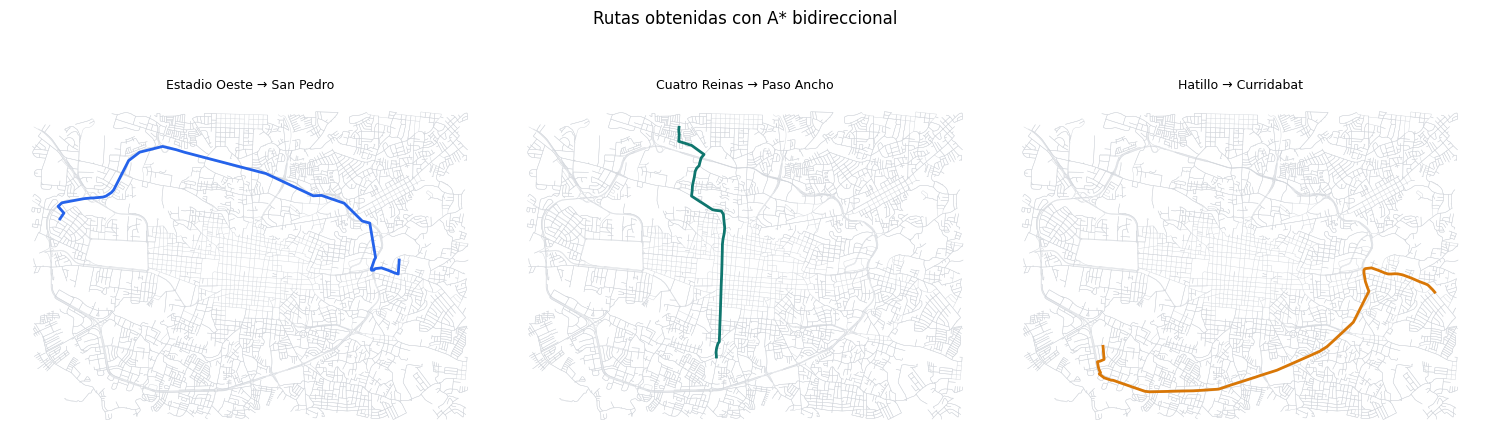

In [5]:
graficar_rutas(grafo, rutas_para_grafico, FIGURAS / "04_rutas_astar.png")
plt.show()

**Figura 4 (Lectura):** la línea coloreada sigue la secuencia de arcos dirigida elegida por
A*. El trazado se desvía de la línea recta por calles de un solo sentido o porque una vía algo
más larga permite mayor velocidad. La igualdad numérica con Dijkstra (celda anterior) confirma
el costo óptimo de los tres recorridos.

## 3. Modelo 2: simulación Monte Carlo estocástica (Tema 4 — Simulación de Monte Carlo)

Sobre cada ruta ya fija (óptima y base) se generan 1000 escenarios. El tiempo de cada arco se
multiplica por un factor lognormal cuya dispersión depende de la clase vial, y cada escenario
recibe además un factor general compartido (lluvia, tráfico). La ruta **no** se recalcula: el
modelo estocástico solo mide qué tan sensible es el tiempo ya obtenido.

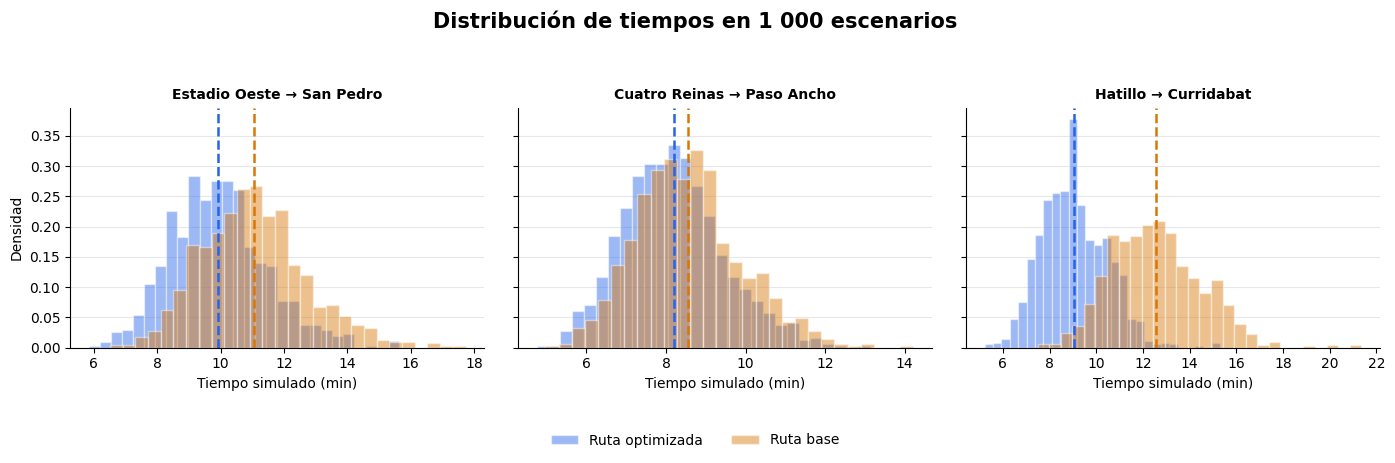

In [6]:
simulaciones = comparar_simulaciones(grafo, comparaciones)
graficar_simulaciones(simulaciones, FIGURAS / "05_simulacion_tiempos.png")
plt.show()

**Figura 5 (Lectura):** las distribuciones de las rutas optimizadas se desplazan hacia
tiempos menores y presentan, en general, menor dispersión que sus referencias base.

,Par,Tiempo óptimo (min),Tiempo base (min),RT %,RV %,IC %,NE,NE Dijkstra
0,Estadio Oeste → San Pedro,9.96,11.11,10.35,9.16,84.2,4235.0,4877
1,Cuatro Reinas → Paso Ancho,8.22,8.59,4.32,4.34,84.0,3094.0,3245
2,Hatillo → Curridabat,8.98,12.45,27.86,27.72,82.2,3197.0,4105


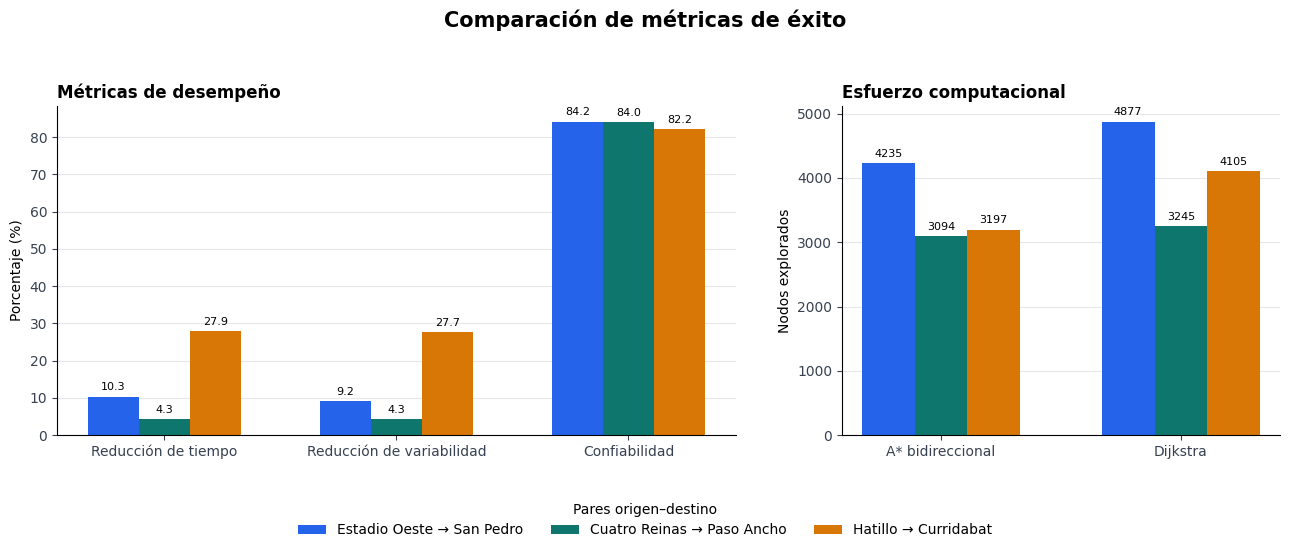

In [7]:
resultados_presentacion = usar_nombres_visuales(resultados)
display(resultados_presentacion[[
    "Par", "Tiempo óptimo (min)", "Tiempo base (min)",
    "RT %", "RV %", "IC %", "NE", "NE Dijkstra"
]].round(2))
graficar_metricas(resultados, FIGURAS / "06_metricas_exito.png")
plt.show()

**Figura 6 (Lectura):** en promedio, las rutas calculadas por el Modelo 1 reducen el
tiempo estimado y, evaluadas por el Modelo 2, también reducen la variabilidad simulada frente a
sus referencias base. A* exploró consistentemente menos nodos que Dijkstra, aunque con mayor
costo de cómputo por mantener dos fronteras.

In [8]:
RAIZ_PROC = DATOS_PROC
resultados.to_csv(RAIZ_PROC / "resultados_rutas.csv", index=False)
simulaciones.to_csv(RAIZ_PROC / "simulaciones_monte_carlo.csv", index=False)
print("Guardado: data/processed/resultados_rutas.csv y simulaciones_monte_carlo.csv")

Guardado: data/processed/resultados_rutas.csv y simulaciones_monte_carlo.csv


Con el Modelo 1 y el Modelo 2 ya aplicados y sus resultados guardados en
`data/processed/`, el notebook `03_validacion.ipynb` retoma estas mismas rutas para la
validación extendida, la comparación cuantitativa entre modelos y el análisis de
sensibilidad.